## Final Project

# In this project, we have a dataset 

Import statements

In [7]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing 
from sklearn import linear_model
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import PolynomialFeatures

Dataset

In [8]:
df = pd.read_csv('netflix_user_behavior_dataset.csv')
print(df.shape)

(50000, 20)


Data 

In [9]:
print(df.shape)
print(df.head())
print('\nTypes:\n', df.dtypes)
print('\nColumns:', df.columns.tolist())
print('\nNull Values:', df.isnull().sum())

(50000, 20)
   user_id  age  gender country  account_age_months subscription_type  \
0  U100000   56    Male   India                  17          Standard   
1  U100001   46  Female     USA                  20          Standard   
2  U100002   32   Other     USA                  25             Basic   
3  U100003   60    Male  Canada                  37          Standard   
4  U100004   25    Male  Brazil                  23           Premium   

   monthly_fee payment_method primary_device  devices_used favorite_genre  \
0        15.99         PayPal         Laptop             1         Sci-Fi   
1        12.99         PayPal         Tablet             2    Documentary   
2        15.99         PayPal         Tablet             2         Comedy   
3        12.99         PayPal       Smart TV             3         Action   
4        12.99         PayPal         Mobile             3         Horror   

   avg_watch_time_minutes  watch_sessions_per_week  binge_watch_sessions  \
0         

### Histograms of Features and Density Plots

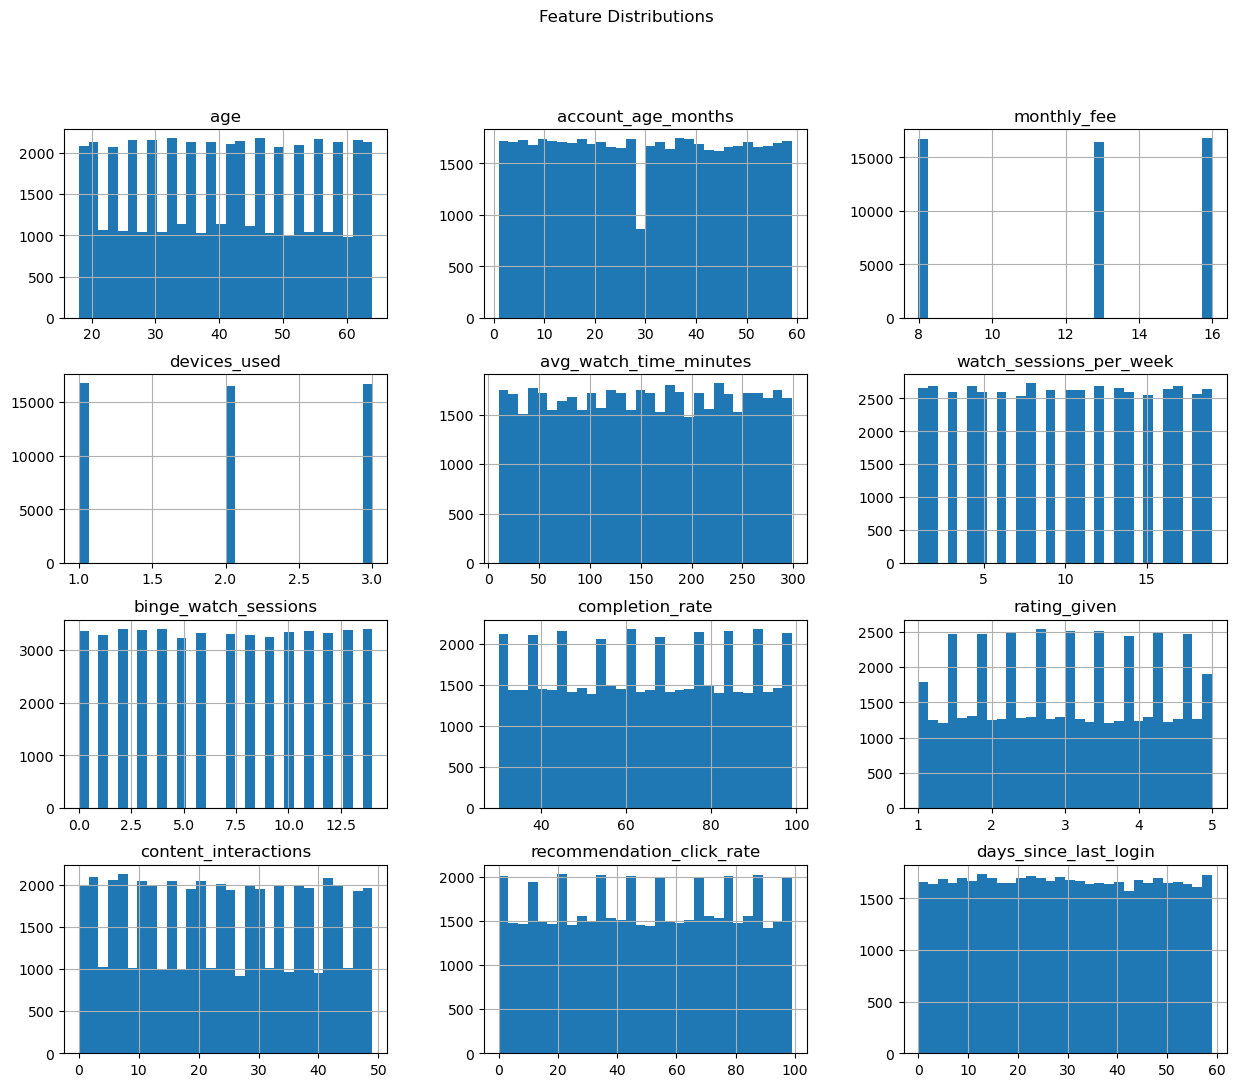

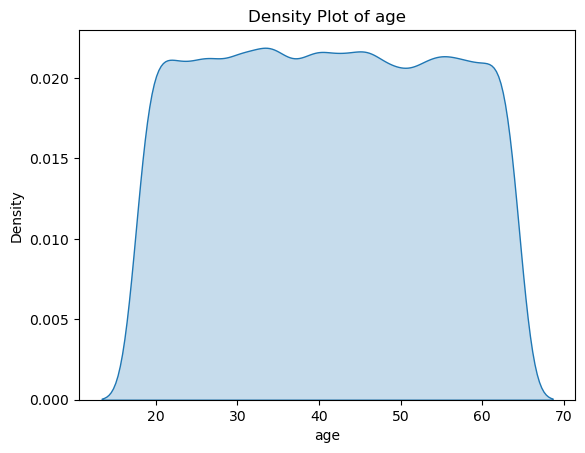

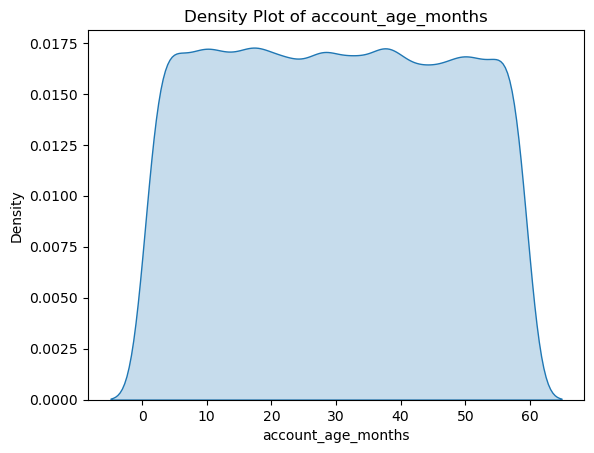

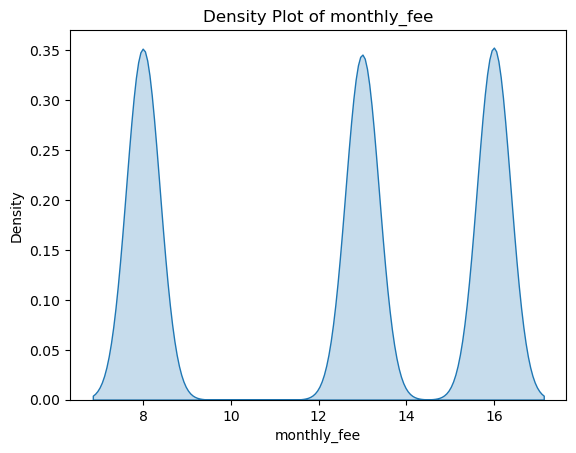

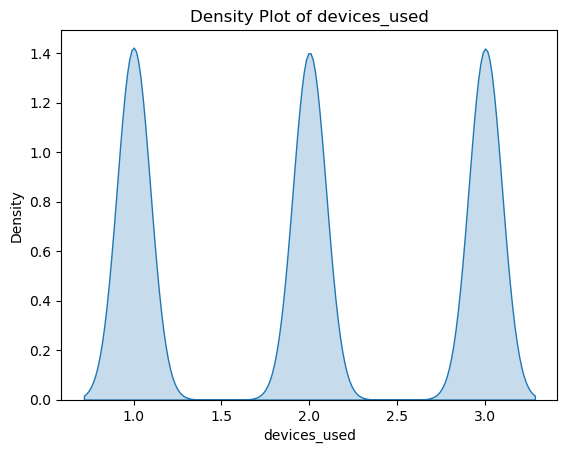

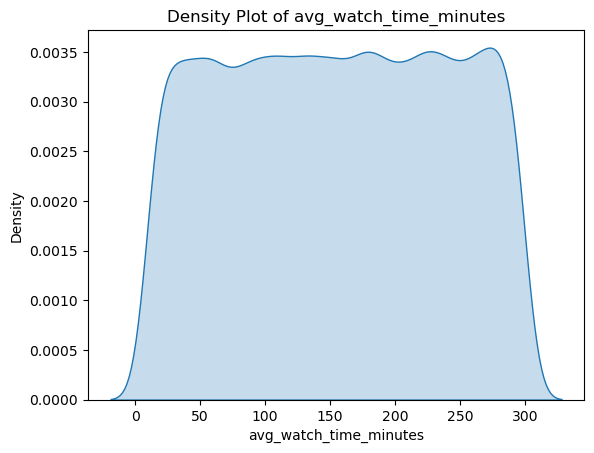

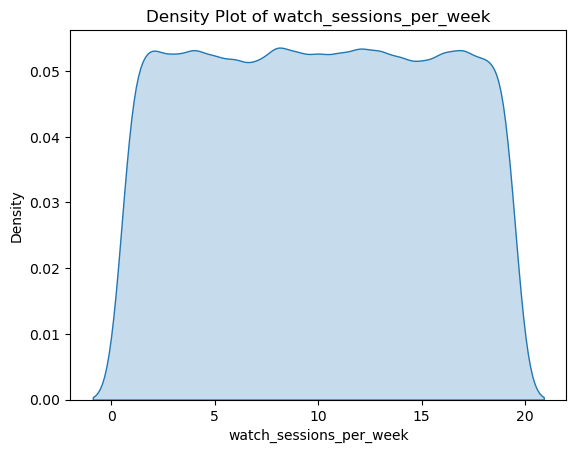

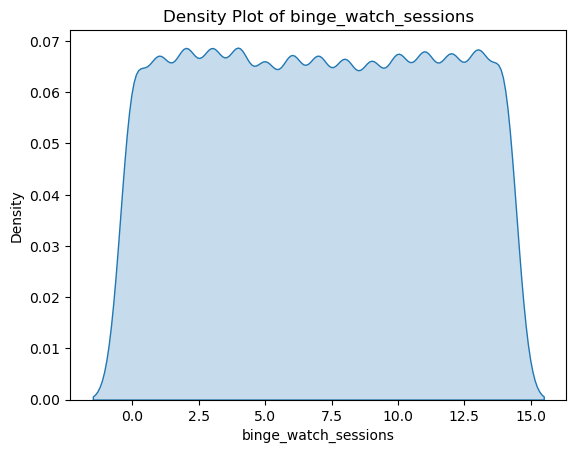

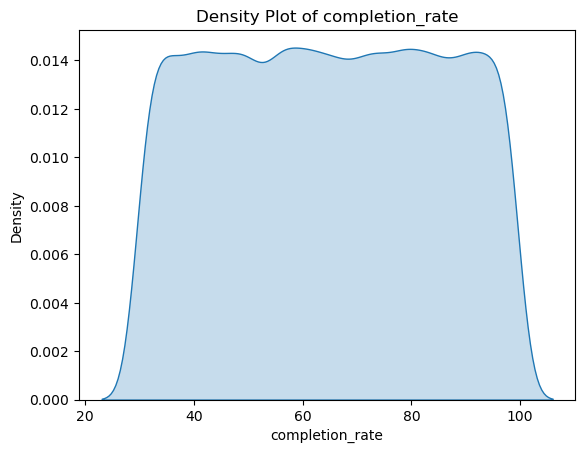

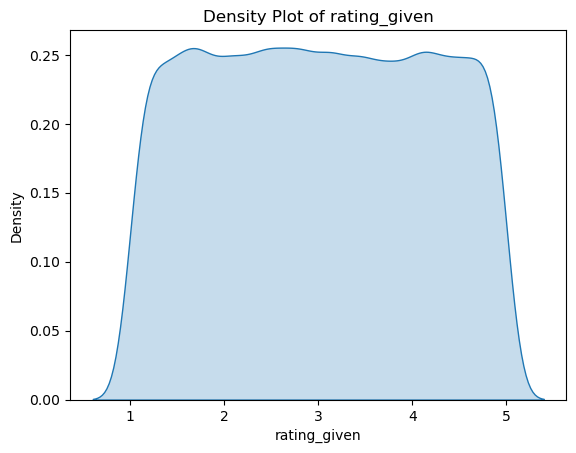

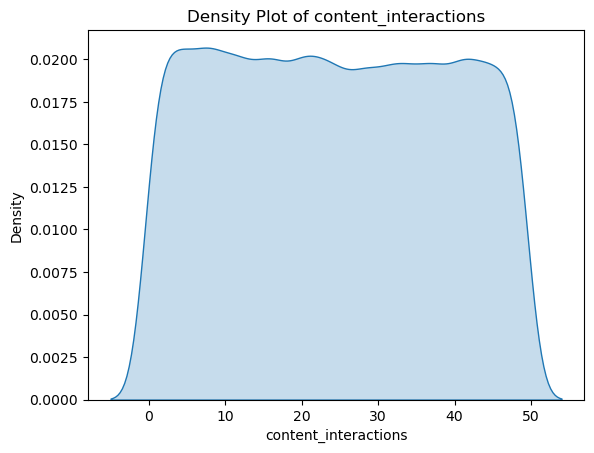

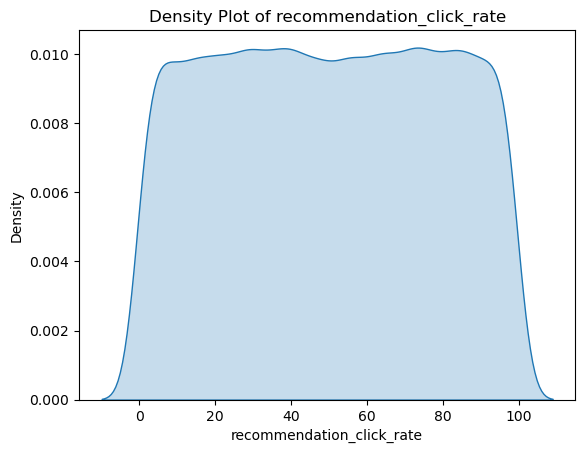

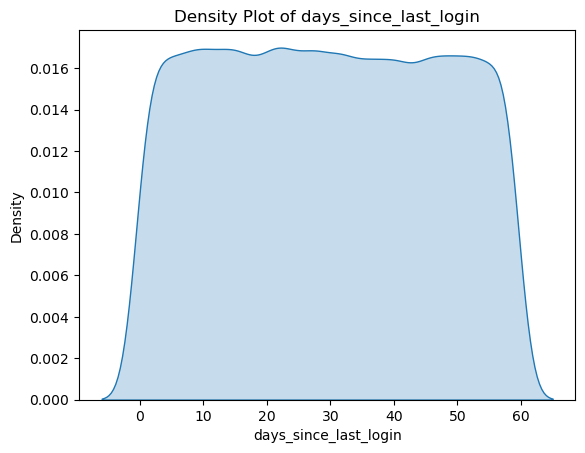

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms
df.hist(figsize=(15,12), bins=30)
plt.suptitle("Feature Distributions")
plt.show()

# Density plots for numeric features
for col in df.select_dtypes(include=np.number).columns:
    sns.kdeplot(df[col], fill=True)
    plt.title(f'Density Plot of {col}')
    plt.show()

Split into Training, Validation, and Testing

In [11]:
df_encoded = pd.get_dummies(df, columns=['gender', 'country', 'subscription_type', 'payment_method','primary_device','favorite_genre'],dtype=int)
df = df_encoded
print(df.head())

   user_id  age  account_age_months  monthly_fee  devices_used  \
0  U100000   56                  17        15.99             1   
1  U100001   46                  20        12.99             2   
2  U100002   32                  25        15.99             2   
3  U100003   60                  37        12.99             3   
4  U100004   25                  23        12.99             3   

   avg_watch_time_minutes  watch_sessions_per_week  binge_watch_sessions  \
0                     220                       17                     3   
1                      76                       15                     4   
2                     215                        6                    13   
3                     280                        4                     9   
4                     261                       15                     9   

   completion_rate  rating_given  ...  primary_device_Smart TV  \
0               60           1.7  ...                        0   
1             

In [12]:
df=df.drop('user_id', axis=1)
print(df.head())

   age  account_age_months  monthly_fee  devices_used  avg_watch_time_minutes  \
0   56                  17        15.99             1                     220   
1   46                  20        12.99             2                      76   
2   32                  25        15.99             2                     215   
3   60                  37        12.99             3                     280   
4   25                  23        12.99             3                     261   

   watch_sessions_per_week  binge_watch_sessions  completion_rate  \
0                       17                     3               60   
1                       15                     4               71   
2                        6                    13               33   
3                        4                     9               58   
4                       15                     9               64   

   rating_given  content_interactions  ...  primary_device_Smart TV  \
0           1.7            

In [13]:
df['churned'] = (df['churned'] == 'Yes').astype(int)

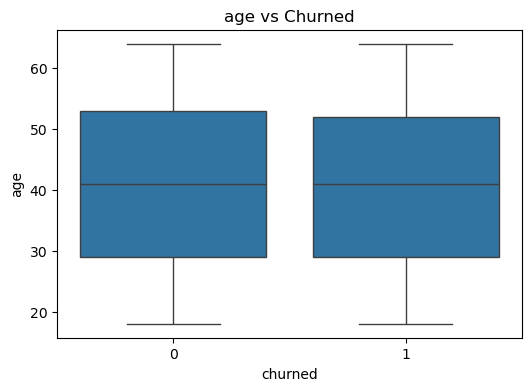

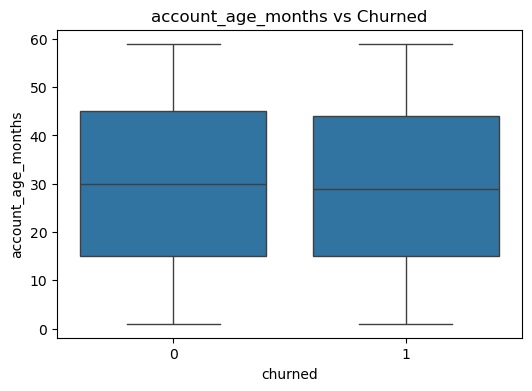

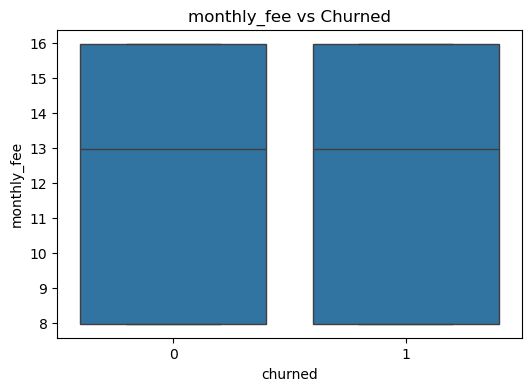

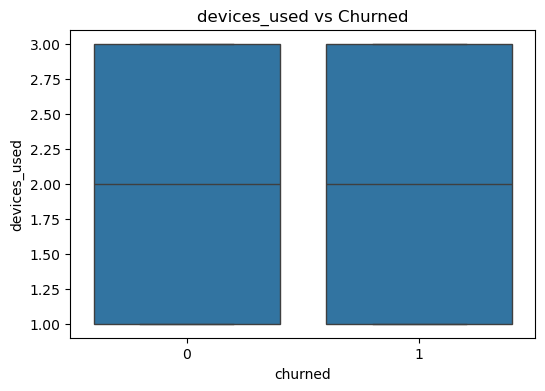

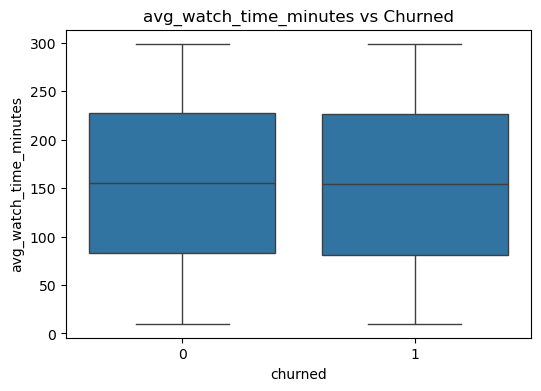

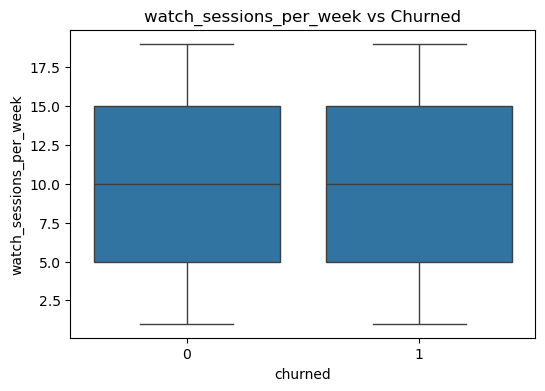

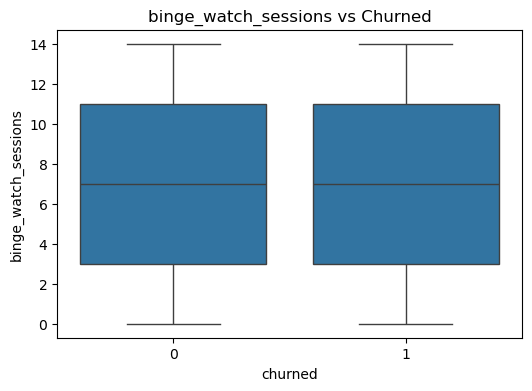

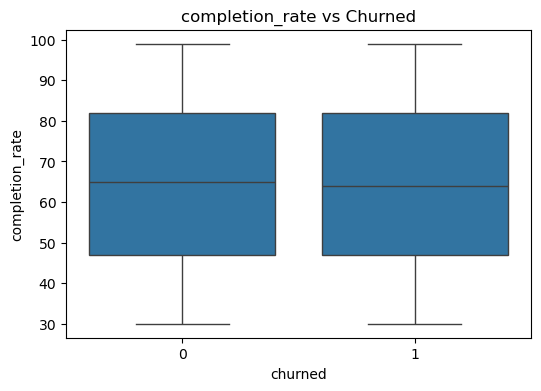

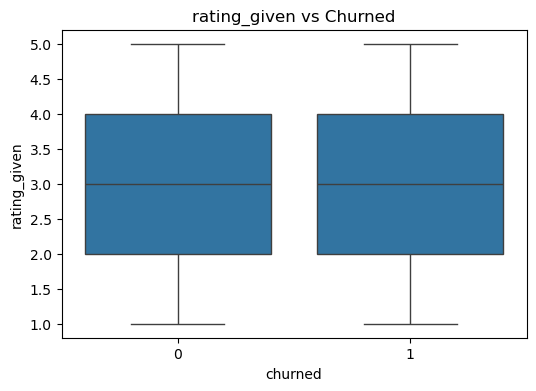

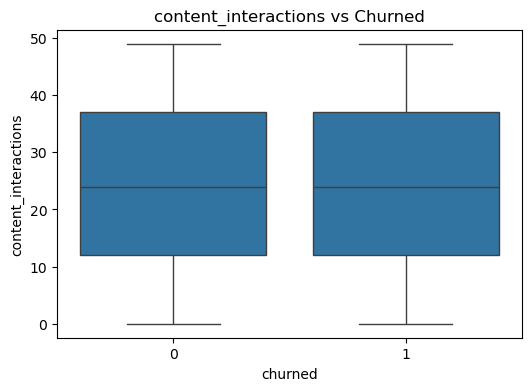

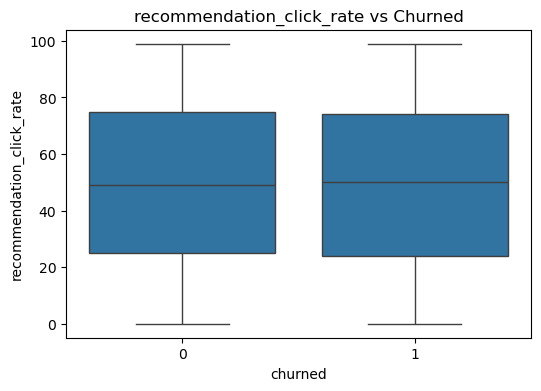

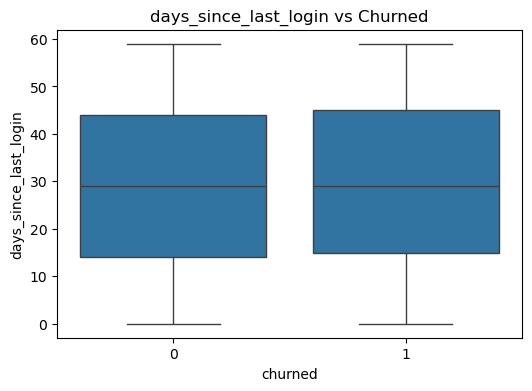

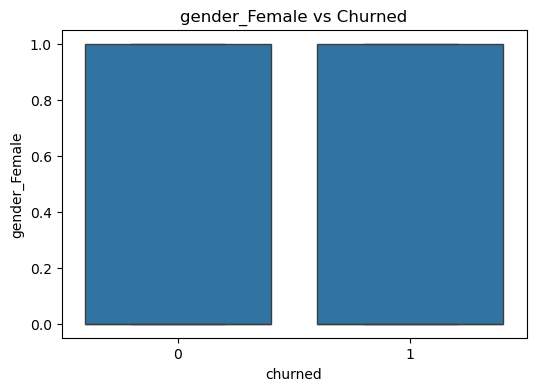

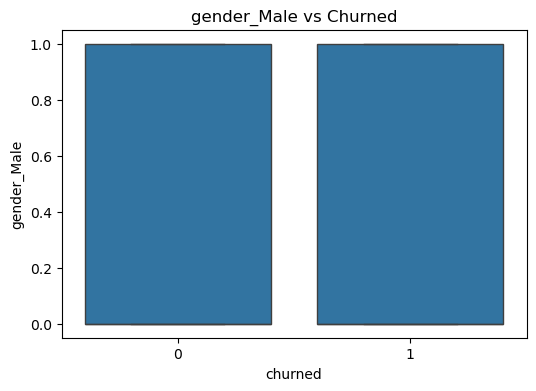

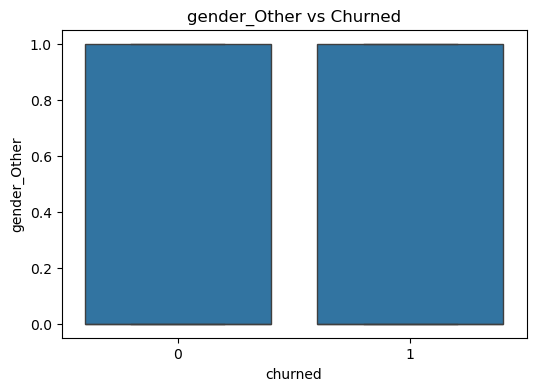

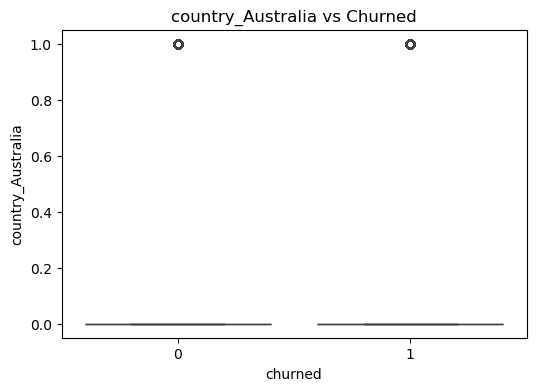

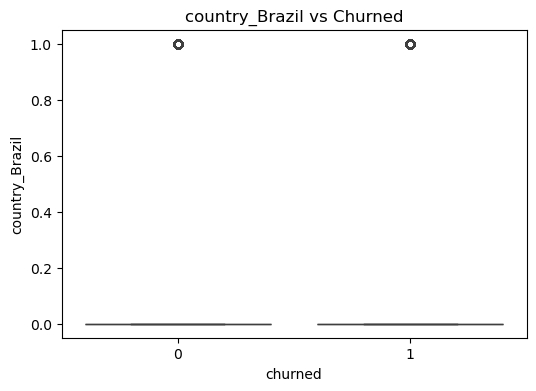

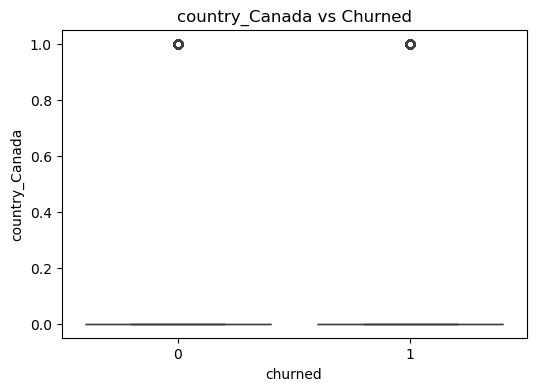

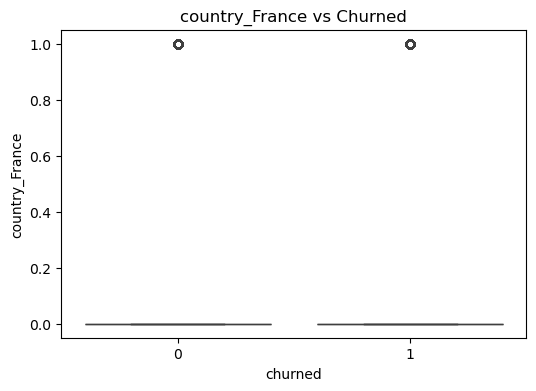

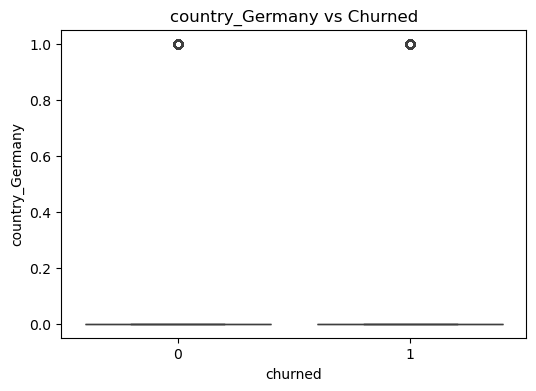

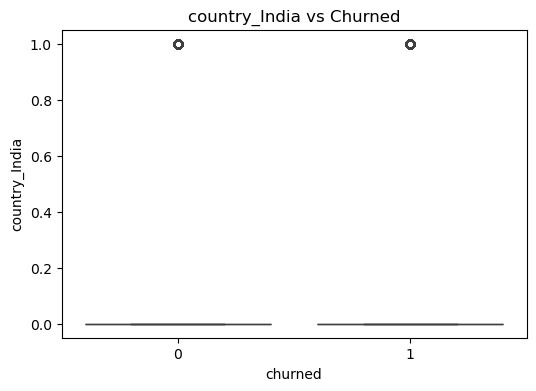

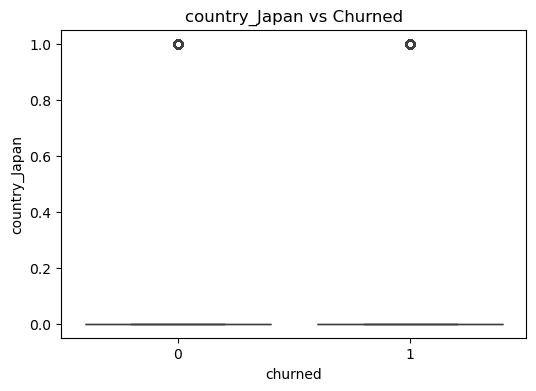

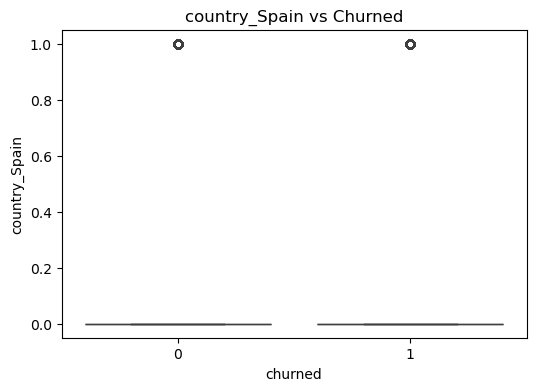

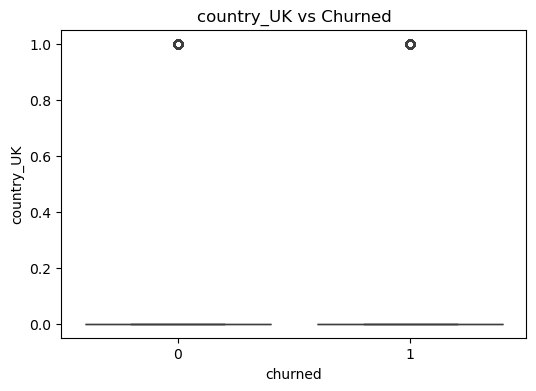

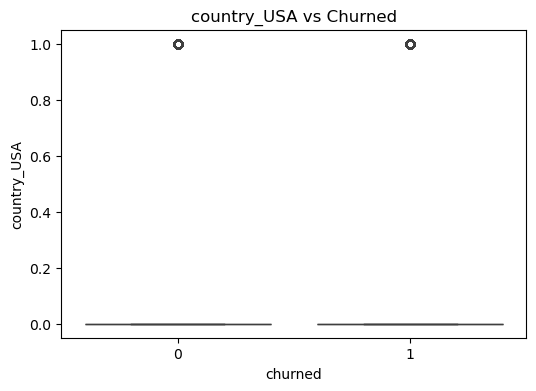

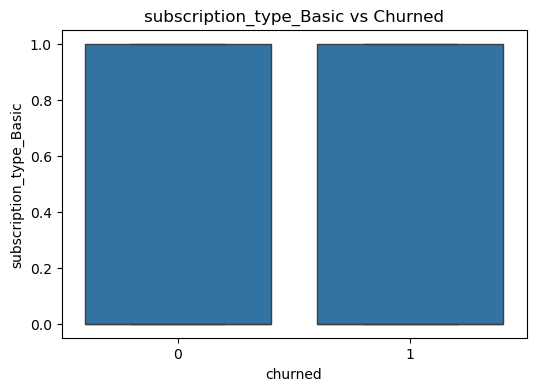

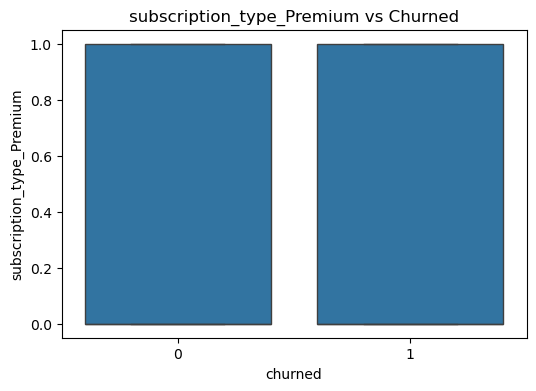

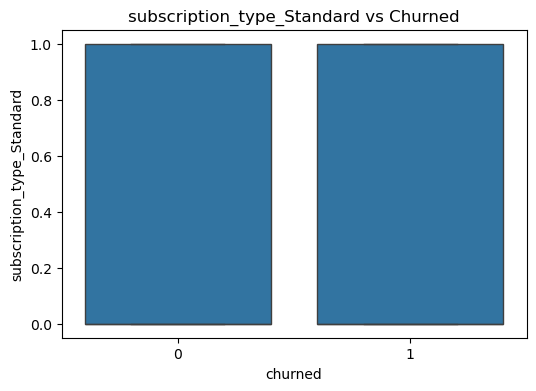

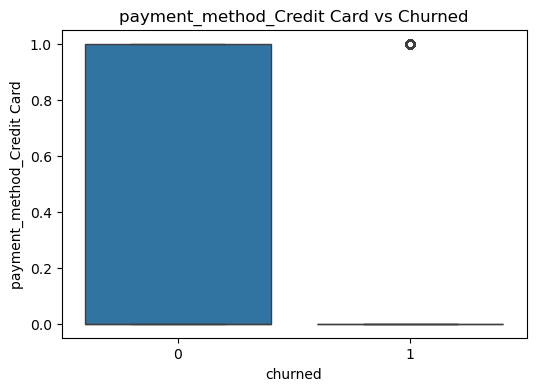

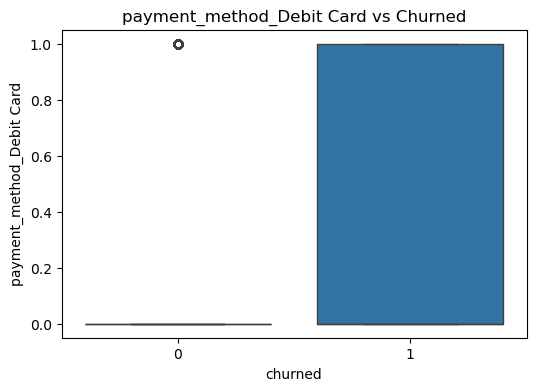

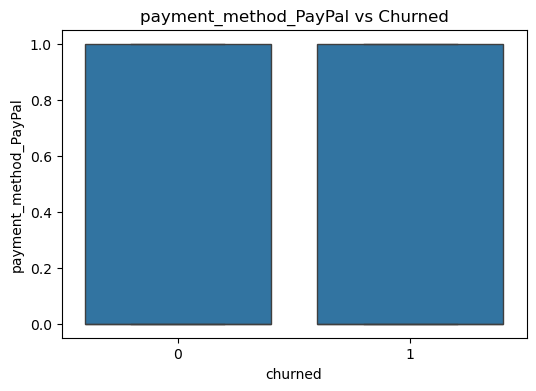

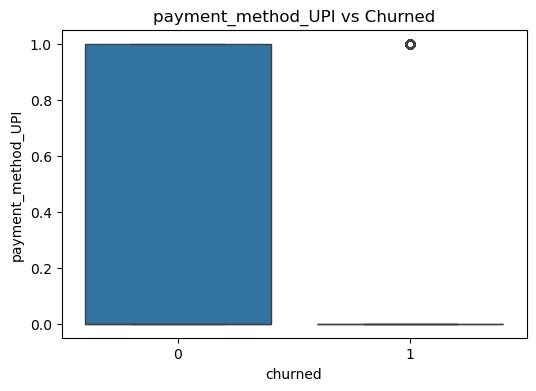

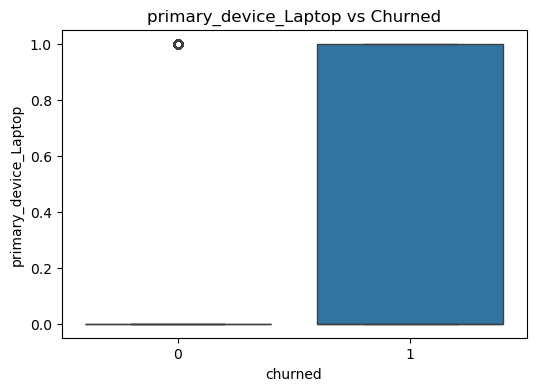

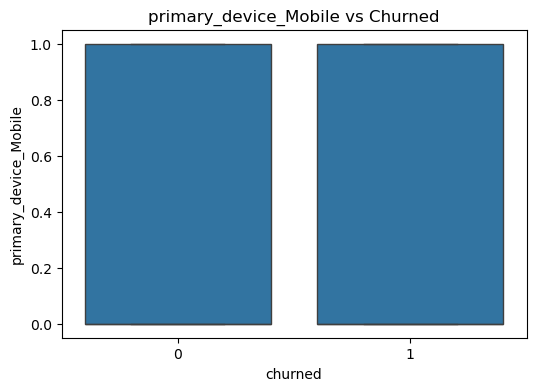

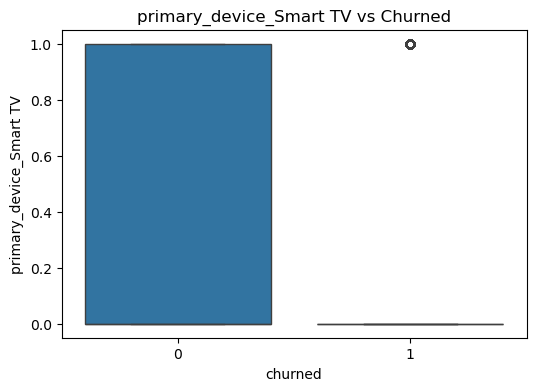

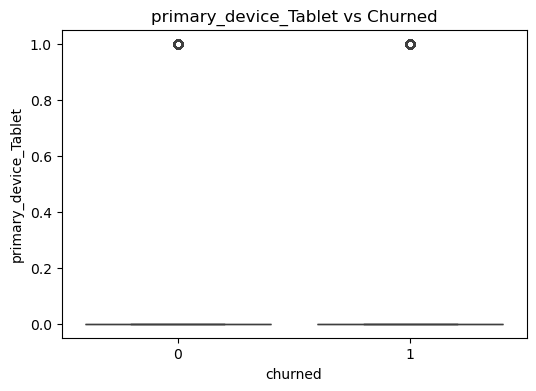

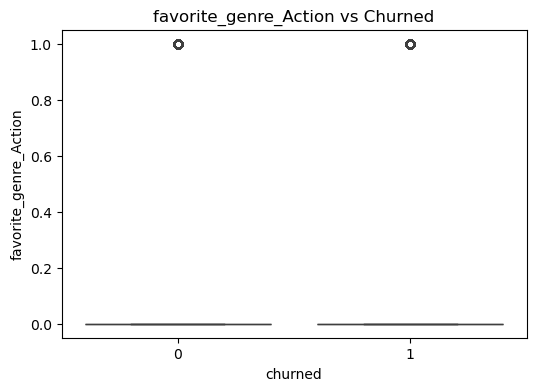

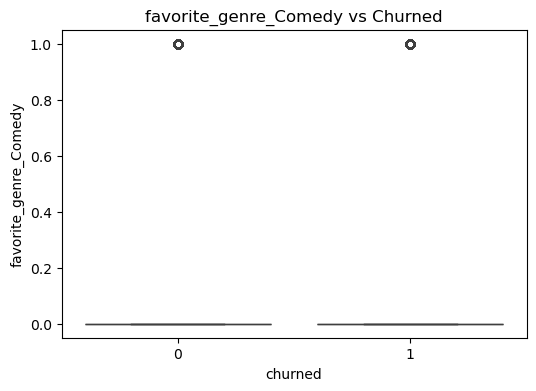

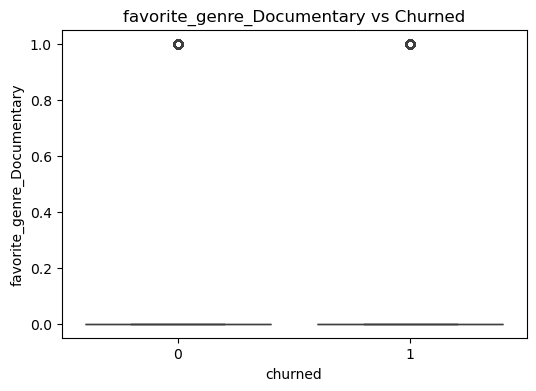

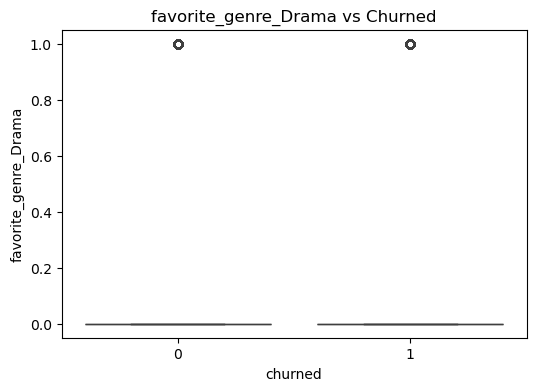

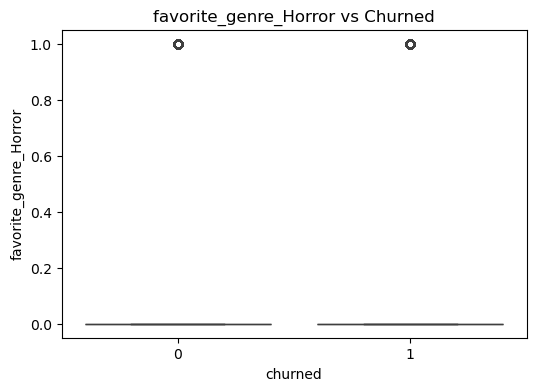

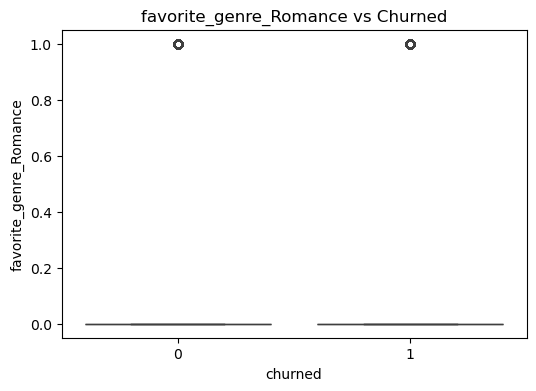

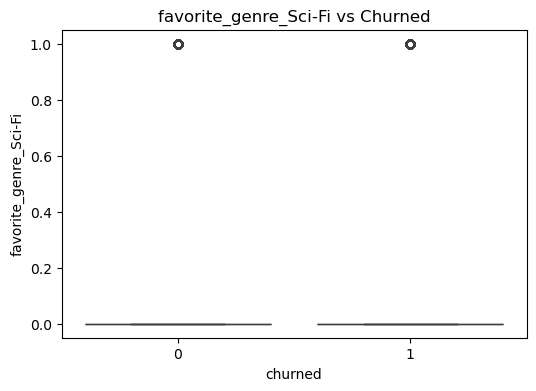

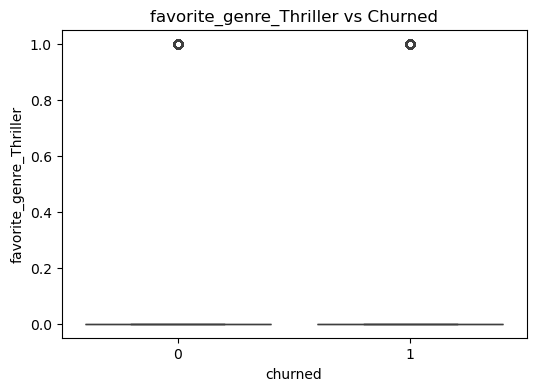

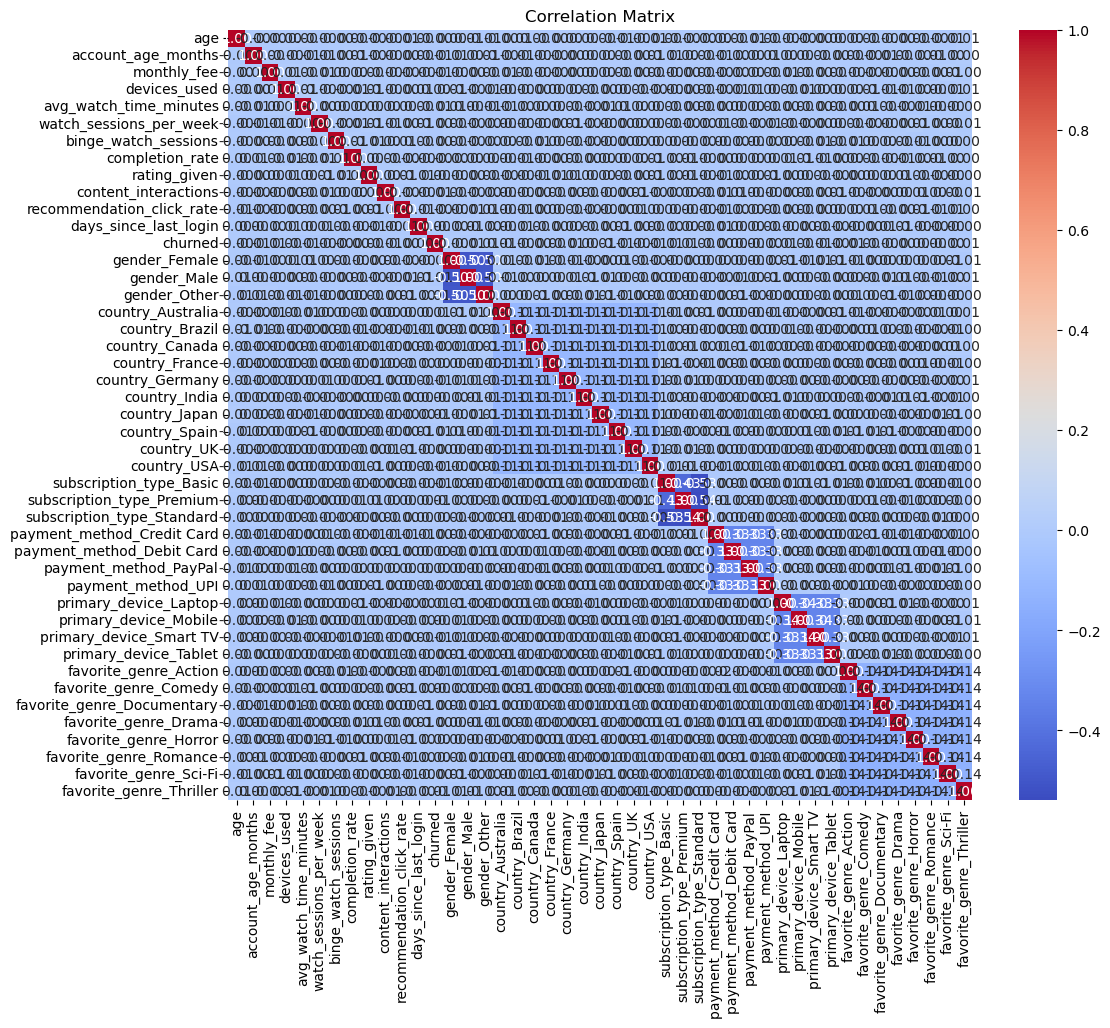

In [14]:
# Boxplots of features vs target
for col in df.drop('churned', axis=1).columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df['churned'], y=df[col])
    plt.title(f'{col} vs Churned')
    plt.show()

# Correlation matrix
plt.figure(figsize=(12,10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [15]:
X = df.iloc[:,0:-1]
print(X.shape)
y = df.iloc[:, -1]
print(y.shape)

(50000, 44)
(50000,)


In [16]:
X_train, X_other, y_train, y_other = train_test_split(X, y, test_size = 0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_other, y_other, test_size = 0.5, random_state=42)

# X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=21)

# Convert after the split
X_train = X_train.to_numpy()
X_val = X_val.to_numpy()
X_test = X_test.to_numpy()

# Doing the same for the labels (y)
y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(35000, 44)
(7500, 44)
(7500, 44)


### Scaling

In [17]:
scaler = StandardScaler()
scaler.fit(X_train)
# scale the traing, validation, and testing data using the fitted scaler.
X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Reshape y_train into 2D array, and y_test into 2D array 
y_2d_train = y_train.reshape(-1, 1)
y_2d_val = y_val.reshape(-1,1)
y_2d_test = y_test.reshape(-1, 1)


In [18]:
print('X_train.shape: ', X_train.shape)
print('y_2d_train.shape: ', y_2d_train.shape)

X_train.shape:  (35000, 44)
y_2d_train.shape:  (35000, 1)


# SKLEARN IMPLEMENTATION OF LOGISTIC REGRESSION

In [28]:
C_values = [0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
degree_values = [1, 2, 3]

In [25]:
#INCLUDING VALIDATION SET

best_val_acc = 0
best_model = None
best_params = None
results_dict = {}

for d in degree_values:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    results = []
    
    for c in C_values:
        logreg = LogisticRegression(C=c, penalty='l2', max_iter=5000)

        X_train_poly = poly.fit_transform(X_train)
        X_val_poly = poly.transform(X_val)
        X_test_poly = poly.transform(X_test)

        logreg.fit(X_train_poly, y_train)

        val_acc = logreg.score(X_val_poly, y_val)

        results.append(val_acc)

        print(f"[VAL] Degree={d}, C={c} → Acc={val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = logreg
            best_params = (c, d)
            best_poly = poly
    results_dict[d] = results
            
    
   
            
print("\nBest Parameters:")
print(f"C = {best_params[0]}, Degree = {best_params[1]}")
print(f"Best Validation Accuracy = {best_val_acc:.4f}")

# Transform test data using BEST transformation
X_test_best = best_poly.transform(X_test)

# Final test evaluation
y_pred = best_model.predict(X_test_best)

print("\n===== FINAL TEST PERFORMANCE =====")
print("Test Accuracy:", best_model.score(X_test_best, y_test))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[VAL] Degree=1, C=1e-06 → Acc=0.8768
[VAL] Degree=1, C=1e-05 → Acc=0.8768
[VAL] Degree=1, C=0.0001 → Acc=0.8768
[VAL] Degree=1, C=0.001 → Acc=0.9987
[VAL] Degree=1, C=0.01 → Acc=1.0000
[VAL] Degree=1, C=0.1 → Acc=1.0000
[VAL] Degree=1, C=1.0 → Acc=1.0000
[VAL] Degree=1, C=10.0 → Acc=1.0000
[VAL] Degree=1, C=100.0 → Acc=1.0000
[VAL] Degree=2, C=1e-06 → Acc=0.8768
[VAL] Degree=2, C=1e-05 → Acc=0.8768
[VAL] Degree=2, C=0.0001 → Acc=0.8851
[VAL] Degree=2, C=0.001 → Acc=1.0000
[VAL] Degree=2, C=0.01 → Acc=1.0000
[VAL] Degree=2, C=0.1 → Acc=1.0000
[VAL] Degree=2, C=1.0 → Acc=1.0000
[VAL] Degree=2, C=10.0 → Acc=1.0000
[VAL] Degree=2, C=100.0 → Acc=1.0000
[VAL] Degree=3, C=1e-06 → Acc=0.8768
[VAL] Degree=3, C=1e-05 → Acc=0.9308
[VAL] Degree=3, C=0.0001 → Acc=1.0000
[VAL] Degree=3, C=0.001 → Acc=1.0000
[VAL] Degree=3, C=0.01 → Acc=1.0000
[VAL] Degree=3, C=0.1 → Acc=1.0000
[VAL] Degree=3, C=1.0 → Acc=1.0000
[VAL] Degree=3, C=10.0 → Acc=1.0000
[VAL] Degree=3, C=100.0 → Acc=1.0000

Best Parameters

In [26]:
print("LOG TRANSFORM RESULTS \n")

# Apply log transform (safe version)
X_train_log = np.log1p(np.abs(X_train))
X_val_log = np.log1p(np.abs(X_val))
X_test_log = np.log1p(np.abs(X_test))

log_results = []
for c in C_values:
    logreg = LogisticRegression(C=c, penalty='l2', max_iter=5000)

    # Train on transformed data
    logreg.fit(X_train_log, y_train)

    # VALIDATION performance (for tuning)
    val_acc = logreg.score(X_val_log, y_val)
    log_results.append(val_acc)

    print(f"[LOG][VAL] C={c} → Acc={val_acc:.4f}")

    # (Optional) still print test performance for inspection
    y_pred = logreg.predict(X_test_log)
    test_acc = logreg.score(X_test_log, y_test)

    print(f"[LOG][TEST] C={c} → Acc={test_acc:.4f}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    


LOG TRANSFORM RESULTS 

[LOG][VAL] C=1e-06 → Acc=0.8768
[LOG][TEST] C=1e-06 → Acc=0.8784
[[6588    0]
 [ 912    0]]
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      6588
           1       0.00      0.00      0.00       912

    accuracy                           0.88      7500
   macro avg       0.44      0.50      0.47      7500
weighted avg       0.77      0.88      0.82      7500

[LOG][VAL] C=1e-05 → Acc=0.8768
[LOG][TEST] C=1e-05 → Acc=0.8784
[[6588    0]
 [ 912    0]]


C:\Users\arnav\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\arnav\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\arnav\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\arnav\anaconda3\Lib\site-packag

              precision    recall  f1-score   support

           0       0.88      1.00      0.94      6588
           1       0.00      0.00      0.00       912

    accuracy                           0.88      7500
   macro avg       0.44      0.50      0.47      7500
weighted avg       0.77      0.88      0.82      7500

[LOG][VAL] C=0.0001 → Acc=0.8768
[LOG][TEST] C=0.0001 → Acc=0.8784
[[6588    0]
 [ 912    0]]
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      6588
           1       0.00      0.00      0.00       912

    accuracy                           0.88      7500
   macro avg       0.44      0.50      0.47      7500
weighted avg       0.77      0.88      0.82      7500

[LOG][VAL] C=0.001 → Acc=0.8768
[LOG][TEST] C=0.001 → Acc=0.8784
[[6588    0]
 [ 912    0]]
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      6588
           1       0.00      0.00      0.00       9

C:\Users\arnav\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\arnav\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\arnav\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6588
           1       1.00      1.00      1.00       912

    accuracy                           1.00      7500
   macro avg       1.00      1.00      1.00      7500
weighted avg       1.00      1.00      1.00      7500

[LOG][VAL] C=0.1 → Acc=1.0000
[LOG][TEST] C=0.1 → Acc=1.0000
[[6588    0]
 [   0  912]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6588
           1       1.00      1.00      1.00       912

    accuracy                           1.00      7500
   macro avg       1.00      1.00      1.00      7500
weighted avg       1.00      1.00      1.00      7500

[LOG][VAL] C=1.0 → Acc=1.0000
[LOG][TEST] C=1.0 → Acc=1.0000
[[6588    0]
 [   0  912]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6588
           1       1.00      1.00      1.00       912

    ac

PLOTTING!!!!!!!!!!!


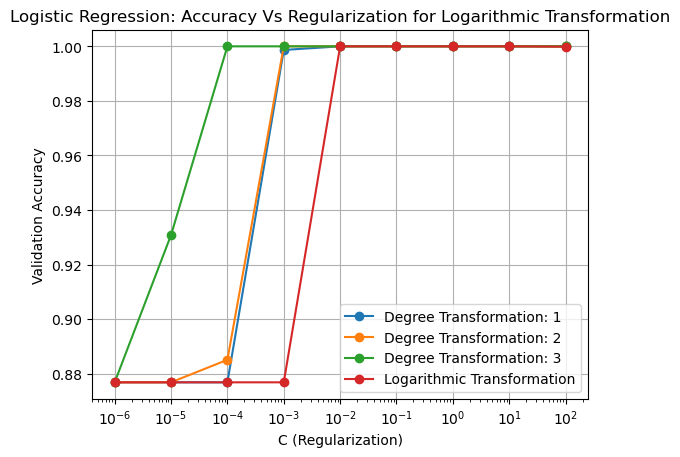

In [33]:
print("PLOTTING!!!!!!!!!!!")

plt.figure()
for key in results_dict:
    plt.plot(C_values, results_dict[key], marker='o', label=f"Degree Transformation: {key}")

plt.plot(C_values, log_results, marker='o', label="Logarithmic Transformation")
plt.title("Logistic Regression: Accuracy Vs Regularization")
plt.xscale('log')
plt.xlabel("C (Regularization)")
plt.ylabel("Validation Accuracy")
plt.title(f"Logistic Regression: Accuracy Vs Regularization for Logarithmic Transformation")
plt.legend()
plt.grid()
plt.show()


# SUPPORT VECTOR MACHINE

In [22]:
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [23]:
model = SVC()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [24]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6588
           1       1.00      1.00      1.00       912

    accuracy                           1.00      7500
   macro avg       1.00      1.00      1.00      7500
weighted avg       1.00      1.00      1.00      7500



## Neural Networks